# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn import linear_model
import scipy.stats as stat
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import accuracy_score, classification_report

# Loading the Data


In [ ]:
loan_data_inputs_train = pd.read_csv('loan_data_inputs_train.csv', index_col = 0)
loan_data_targets_train = pd.read_csv('loan_data_targets_train.csv', index_col = 0)
loan_data_inputs_test = pd.read_csv('loan_data_inputs_test.csv', index_col = 0)
loan_data_targets_test = pd.read_csv('loan_data_targets_test.csv', index_col = 0)

In [ ]:
loan_data_inputs_train.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,months_since_earliest_cr_line,issue_d_date,months_since_issue_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,home_ownership:RENT_OTHER_NONE_ANY,addr_state:ND,addr_state:ND_NE_IA_NV_AL_FL,addr_state:MO_HI_NC_LA,addr_state:NH_AK_MS_WV_WY_DC_ME_ID,addr_state:CO_CT_SC_VT,addr_state:IL_KS,addr_state:OR_MT_WI,addr_state:GA_MN_IN_WA,addr_state:DE_MA_UT_KY,addr_state:PA_SD_OH,addr_state:NM_AZ_RI_MI_AR_TN,purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation,purpose:vacation_major_purch__car__home_impr,term:36,term:60,emp_length:0,emp_length:1-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d_factor,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,mths_since_issue_d:>84,int_rate_factor,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,funded_amnt_factor,mths_since_earliest_cr_line_factor,

In [ ]:
loan_data_inputs_train.shape

(373028, 321)

In [ ]:
loan_data_targets_train.shape

(373028, 1)

In [ ]:
loan_data_inputs_test.shape

(93257, 321)

In [ ]:
loan_data_targets_test.shape

(93257, 1)

# Prepare X_train, y_train

In [ ]:
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:MORTGAGE',
'home_ownership:OWN',
'home_ownership:RENT_OTHER_NONE_ANY',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:credit_card',
'purpose:debt_consolidation',
'addr_state:CA',
'addr_state:NY',
'addr_state:TX',
'initial_list_status:f',
'initial_list_status:w',
'addr_state:ND_NE_IA_NV_AL_FL',
'addr_state:MO_HI_NC_LA',
'addr_state:NH_AK_MS_WV_WY_DC_ME_ID',
'addr_state:CO_CT_SC_VT',
'addr_state:IL_KS',
'addr_state:OR_MT_WI',
'addr_state:GA_MN_IN_WA',
'addr_state:DE_MA_UT_KY',
'addr_state:PA_SD_OH',
'addr_state:NM_AZ_RI_MI_AR_TN',
'purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation',
'purpose:vacation_major_purch__car__home_impr',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'delinq_2yrs:0',
'delinq_2yrs:1-3',
'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
'total_acc:<=27',
'total_acc:28-51',
'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-125K',
'annual_inc:125K-150K',
'annual_inc:>150K',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86'
]]

In [ ]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'verification_status:Verified',
'initial_list_status:f',
'addr_state:ND_NE_IA_NV_AL_FL',
'purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'delinq_2yrs:>=4',
'inq_last_6mths:>6',
'open_acc:0',
'pub_rec:0-2',
'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20K',
'mths_since_last_delinq:0-3',
'dti:>35',
'mths_since_last_record:0-2'
]

In [ ]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:MORTGAGE,home_ownership:OWN,verification_status:Not Verified,verification_status:Source Verified,purpose:credit_card,purpose:debt_consolidation,addr_state:CA,addr_state:NY,addr_state:TX,initial_list_status:w,addr_state:MO_HI_NC_LA,addr_state:NH_AK_MS_WV_WY_DC_ME_ID,addr_state:CO_CT_SC_VT,addr_state:IL_KS,addr_state:OR_MT_WI,addr_state:GA_MN_IN_WA,addr_state:DE_MA_UT_KY,addr_state:PA_SD_OH,addr_state:NM_AZ_RI_MI_AR_TN,purpose:vacation_major_purch__car__home_impr,term:36,emp_length:1-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,delinq_2yrs:0,delinq_2yrs:1-3,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,open_acc:1-3,open_acc:4-12,open_acc:13-17,open_acc:18-22,open_acc:23-25,open_acc:26-30,open_acc:>=31,pub_rec:3-4,pub_rec:>=5,total_acc:28-51,total_acc:>=52,acc_now_delinq:>=1,total_rev_hi_lim:5K-10K,total_rev_hi_lim:10K-20K,total_rev_hi_lim:20K-30K,total_rev_hi_lim:30K-40K,total_rev_hi_lim:40K-55K,total_rev_hi_lim:55K-95K,total_rev_hi_lim:>95K,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-125K,annual_inc:125K-150K,annual_inc:>150K,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86
25916,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
83271,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
226146,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
424372,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
74133,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0


In [ ]:
class LogisticRegression_with_p_values:

    def __init__(self,*args,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)

    def fit(self,X,y):
        self.model.fit(X,y)

        #### Get p-values for the fitted model ####
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X) ## Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij) ## Inverse Information Matrix
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates # z-score for eaach model coefficient
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] ### two tailed test for p-values

        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [ ]:
reg = LogisticRegression_with_p_values(solver = 'lbfgs', fit_intercept = True ,max_iter = 2000, C = 1, penalty = 'l2', tol = 0.0001)
reg.fit(inputs_train, np.ravel(loan_data_targets_train))

In [ ]:
feature_name =  inputs_train.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-1.574033
1,grade:A,1.011212
2,grade:B,0.884774
3,grade:C,0.704742
4,grade:D,0.531061
5,grade:E,0.346232
6,grade:F,0.180232
7,home_ownership:MORTGAGE,0.103545
8,home_ownership:OWN,0.082259
9,verification_status:Not Verified,0.094137


In [ ]:
p_values = reg.p_values
p_values = np.append(np.nan, np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-1.574033,NaN
1,grade:A,1.011212,7.317980e-28
2,grade:B,0.884774,4.939356e-48
3,grade:C,0.704742,7.170519e-36
4,grade:D,0.531061,3.446854e-23
5,grade:E,0.346232,4.490201e-13
6,grade:F,0.180232,3.030918e-04
7,home_ownership:MORTGAGE,0.103545,3.327742e-16
8,home_ownership:OWN,0.082259,4.289551e-05
9,verification_status:Not Verified,0.094137,1.331703e-10


# Drop a group from which all members are not statistically significant.

In [ ]:
inputs_train_with_ref_cat = loan_data_inputs_train.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:MORTGAGE',
'home_ownership:OWN',
'home_ownership:RENT_OTHER_NONE_ANY',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:credit_card',
'purpose:debt_consolidation',
'addr_state:CA',
'addr_state:NY',
'addr_state:TX',
'initial_list_status:f',
'initial_list_status:w',
'addr_state:ND_NE_IA_NV_AL_FL',
'addr_state:MO_HI_NC_LA',
'addr_state:NH_AK_MS_WV_WY_DC_ME_ID',
'addr_state:CO_CT_SC_VT',
'addr_state:IL_KS',
'addr_state:OR_MT_WI',
'addr_state:GA_MN_IN_WA',
'addr_state:DE_MA_UT_KY',
'addr_state:PA_SD_OH',
'addr_state:NM_AZ_RI_MI_AR_TN',
'purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation',
'purpose:vacation_major_purch__car__home_impr',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-125K',
'annual_inc:125K-150K',
'annual_inc:>150K',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86'
]]

In [ ]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'verification_status:Verified',
'initial_list_status:f',
'addr_state:ND_NE_IA_NV_AL_FL',
'purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation',
'term:60',
'emp_length:0',
'mths_since_issue_d:>84',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'inq_last_6mths:>6',
'open_acc:0',
'acc_now_delinq:0',
'annual_inc:<20K',
'mths_since_last_delinq:0-3',
'dti:>35',
'mths_since_last_record:0-2'
]

In [ ]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)


In [ ]:
reg2 = LogisticRegression_with_p_values(solver = 'lbfgs', fit_intercept = True ,max_iter = 2000, C = 1, penalty = 'l2', tol = 0.0001)
reg2.fit(inputs_train, np.ravel(loan_data_targets_train))

In [ ]:
feature_name = inputs_train.columns.values

summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-1.561431
1,grade:A,1.019756
2,grade:B,0.887897
3,grade:C,0.706868
4,grade:D,0.532870
5,grade:E,0.347438
6,grade:F,0.180800
7,home_ownership:MORTGAGE,0.103993
8,home_ownership:OWN,0.085256
9,verification_status:Not Verified,0.091647


In [ ]:
p_values = reg2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-1.561431,NaN
1,grade:A,1.019756,2.369011e-28
2,grade:B,0.887897,2.121103e-48
3,grade:C,0.706868,4.135518e-36
4,grade:D,0.532870,2.348291e-23
5,grade:E,0.347438,3.674200e-13
6,grade:F,0.180800,2.896002e-04
7,home_ownership:MORTGAGE,0.103993,1.981776e-16
8,home_ownership:OWN,0.085256,2.178095e-05
9,verification_status:Not Verified,0.091647,3.159208e-10


In [ ]:
reg2.model.score(inputs_train, np.ravel(loan_data_targets_train))

0.8906087478687927

# Save model

In [ ]:
pickle.dump(reg2, open('pd_model.sav', 'wb'))

# Performance on test set

In [ ]:
inputs_test_with_ref = loan_data_inputs_test.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:MORTGAGE',
'home_ownership:OWN',
'home_ownership:RENT_OTHER_NONE_ANY',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:credit_card',
'purpose:debt_consolidation',
'addr_state:CA',
'addr_state:NY',
'addr_state:TX',
'initial_list_status:f',
'initial_list_status:w',
'addr_state:ND_NE_IA_NV_AL_FL',
'addr_state:MO_HI_NC_LA',
'addr_state:NH_AK_MS_WV_WY_DC_ME_ID',
'addr_state:CO_CT_SC_VT',
'addr_state:IL_KS',
'addr_state:OR_MT_WI',
'addr_state:GA_MN_IN_WA',
'addr_state:DE_MA_UT_KY',
'addr_state:PA_SD_OH',
'addr_state:NM_AZ_RI_MI_AR_TN',
'purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation',
'purpose:vacation_major_purch__car__home_impr',
'term:36',
'term:60',
'emp_length:0',
'emp_length:1-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mths_since_issue_d:<38',
'mths_since_issue_d:38-39',
'mths_since_issue_d:40-41',
'mths_since_issue_d:42-48',
'mths_since_issue_d:49-52',
'mths_since_issue_d:53-64',
'mths_since_issue_d:65-84',
'mths_since_issue_d:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mths_since_earliest_cr_line:<140',
'mths_since_earliest_cr_line:141-164',
'mths_since_earliest_cr_line:165-247',
'mths_since_earliest_cr_line:248-270',
'mths_since_earliest_cr_line:271-352',
'mths_since_earliest_cr_line:>352',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-17',
'open_acc:18-22',
'open_acc:23-25',
'open_acc:26-30',
'open_acc:>=31',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'annual_inc:<20K',
'annual_inc:20K-30K',
'annual_inc:30K-40K',
'annual_inc:40K-50K',
'annual_inc:50K-60K',
'annual_inc:60K-70K',
'annual_inc:70K-80K',
'annual_inc:80K-90K',
'annual_inc:90K-100K',
'annual_inc:100K-125K',
'annual_inc:125K-150K',
'annual_inc:>150K',
'mths_since_last_delinq:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'dti:<=1.4',
'dti:1.4-3.5',
'dti:3.5-7.7',
'dti:7.7-10.5',
'dti:10.5-16.1',
'dti:16.1-20.3',
'dti:20.3-21.7',
'dti:21.7-22.4',
'dti:22.4-35',
'dti:>35',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86'
]]

## Accuracy and AUC

In [ ]:
y_test = loan_data_targets_test
y_train  = loan_data_targets_train
X_test = inputs_test_with_ref.drop(ref_categories, axis = 1)
X_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)

## Accuracy

In [ ]:
y_pred   = reg2.model.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))

Accuracy on test set: 0.8910323085666492


In [ ]:
y_train_pred = reg2.model.predict(inputs_train)
print("Accuracy on train set:", accuracy_score(y_train, y_train_pred))

Accuracy on train set: 0.8906087478687927


## AUC

In [ ]:
y_pred_prob_test = reg2.model.predict_proba(X_test)[:, 1]

In [ ]:
fpr, tpr, thres = roc_curve(y_test, y_pred_prob_test)

In [ ]:
roc_auc = auc(fpr, tpr)

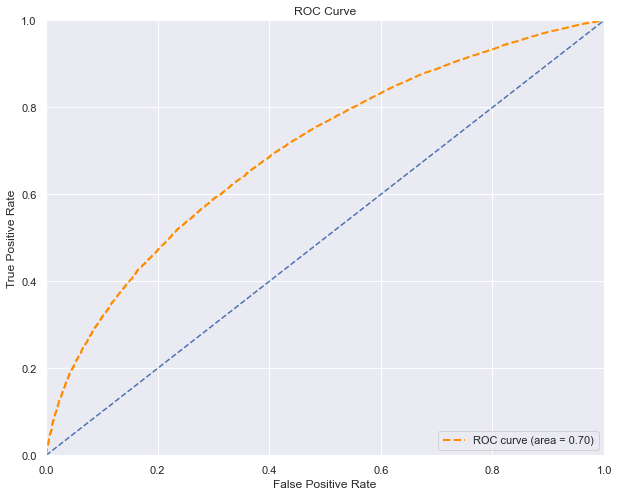

In [ ]:
def _plot_roc_curve(fpr, tpr, thres, auc):
    plt.figure(figsize = (10, 8))
    plt.plot(fpr, tpr, color='darkorange', linestyle='--', lw=2, label='ROC curve (area = %0.2f)' % auc)
    plt.plot([0, 1], [0, 1], '--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.title('ROC Curve')

_plot_roc_curve(fpr, tpr, thres, roc_auc)

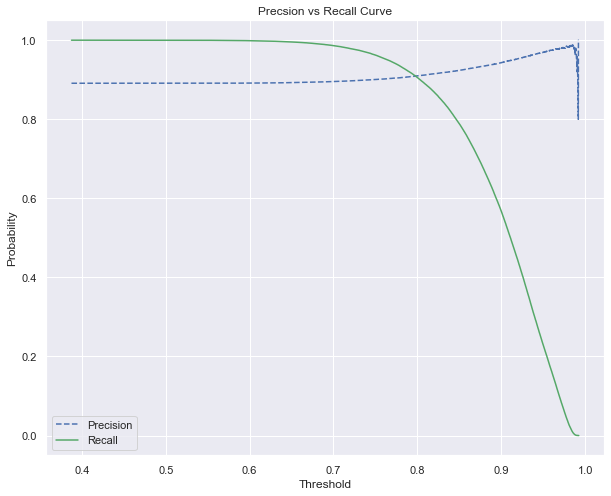

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, thres = precision_recall_curve(y_test, y_pred_prob_test)
def _plot_prec_rec_curve(prec, rec, thres):
    plt.figure(figsize = (10, 8))
    plt.plot(thres, prec[:-1], 'b--', label = 'Precision')
    plt.plot(thres, rec[:-1], 'g-', label = 'Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Probability')
    plt.title('Precsion vs Recall Curve')
    plt.legend()

_plot_prec_rec_curve(precision, recall, thres)

# Calculate Accuracy and draw ROC and calculate AUC manually

In [ ]:
y_pred_prob_test = reg2.model.predict_proba(X_test)[:, 1]
loan_data_targets_test_temp = loan_data_targets_test
loan_data_targets_test_temp.reset_index(drop = True, inplace = True)
df_actual_predicted_probs = pd.concat([loan_data_targets_test_temp, pd.DataFrame(y_pred_prob_test)], axis = 1)

In [ ]:
df_actual_predicted_probs.columns = ['loan_data_targets_test', 'y_hat_test_proba']

In [ ]:
df_actual_predicted_probs.index = loan_data_inputs_test.index

In [ ]:
df_actual_predicted_probs.head()

,loan_data_targets_test,y_hat_test_proba
457433,1,0.890336
302364,1,0.982108
94591,1,0.920503
333935,1,0.942513
121802,1,0.940589


In [ ]:
tr = 0.5
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 1, 0)

In [ ]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,3,10156
1,6,83092


In [ ]:
pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]

Predicted,0,1
Actual,,
0,0.000032,0.108903
1,0.000064,0.891000


In [ ]:
(pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]

0.8910323085666492

Text(0.5, 1.0, 'ROC curve')

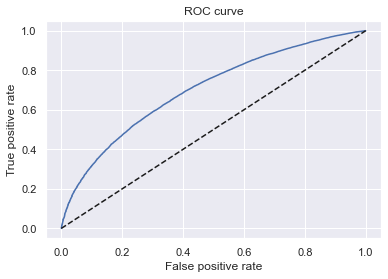

In [ ]:
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [ ]:
AUROC = roc_auc_score(df_actual_predicted_probs['loan_data_targets_test'], df_actual_predicted_probs['y_hat_test_proba'])
AUROC

0.7008734572131078

## Gini coefficient and Kolmogorov-Smirnov coefficient

In [ ]:
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')

In [ ]:
df_actual_predicted_probs.head()

,loan_data_targets_test,y_hat_test_proba,y_hat_test
41422,0,0.373018,0
41048,1,0.387665,0
42368,0,0.462906,0
41966,1,0.467433,0
41033,1,0.473208,0


In [ ]:
df_actual_predicted_probs.tail()

,loan_data_targets_test,y_hat_test_proba,y_hat_test
238767,0,0.991855,1
246553,1,0.992010,1
251900,1,0.992012,1
247902,1,0.992393,1
239228,1,0.992405,1


In [ ]:
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()

In [ ]:
df_actual_predicted_probs['Cumulative N Population'] = df_actual_predicted_probs.index + 1
df_actual_predicted_probs['Cumulative N Good'] = df_actual_predicted_probs['loan_data_targets_test'].cumsum()
df_actual_predicted_probs['Cumulative N Bad'] = df_actual_predicted_probs['Cumulative N Population'] - df_actual_predicted_probs['loan_data_targets_test'].cumsum()


In [ ]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad
0,41422,0,0.373018,0,1,0,1
1,41048,1,0.387665,0,2,1,1
2,42368,0,0.462906,0,3,1,2
3,41966,1,0.467433,0,4,2,2
4,41033,1,0.473208,0,5,3,2


In [ ]:
df_actual_predicted_probs['Cumulative Perc Population'] = df_actual_predicted_probs['Cumulative N Population'] / (df_actual_predicted_probs.shape[0])
df_actual_predicted_probs['Cumulative Perc Good'] = df_actual_predicted_probs['Cumulative N Good'] / df_actual_predicted_probs['loan_data_targets_test'].sum()
df_actual_predicted_probs['Cumulative Perc Bad'] = df_actual_predicted_probs['Cumulative N Bad'] / (df_actual_predicted_probs.shape[0] - df_actual_predicted_probs['loan_data_targets_test'].sum())

In [ ]:
df_actual_predicted_probs.head()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
0,41422,0,0.373018,0,1,0,1,0.000011,0.000000,0.000098
1,41048,1,0.387665,0,2,1,1,0.000021,0.000012,0.000098
2,42368,0,0.462906,0,3,1,2,0.000032,0.000012,0.000197
3,41966,1,0.467433,0,4,2,2,0.000043,0.000024,0.000197
4,41033,1,0.473208,0,5,3,2,0.000054,0.000036,0.000197


In [ ]:
df_actual_predicted_probs.tail()

,index,loan_data_targets_test,y_hat_test_proba,y_hat_test,Cumulative N Population,Cumulative N Good,Cumulative N Bad,Cumulative Perc Population,Cumulative Perc Good,Cumulative Perc Bad
93252,238767,0,0.991855,1,93253,83094,10159,0.999957,0.999952,1.0
93253,246553,1,0.992010,1,93254,83095,10159,0.999968,0.999964,1.0
93254,251900,1,0.992012,1,93255,83096,10159,0.999979,0.999976,1.0
93255,247902,1,0.992393,1,93256,83097,10159,0.999989,0.999988,1.0
93256,239228,1,0.992405,1,93257,83098,10159,1.000000,1.000000,1.0


Text(0.5, 1.0, 'Gini')

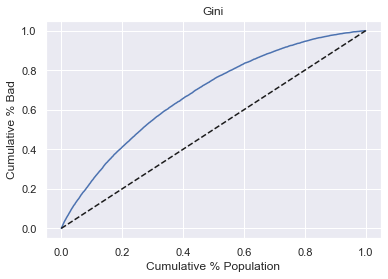

In [ ]:
# Plot Gini
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Bad'])
plt.plot(df_actual_predicted_probs['Cumulative Perc Population'], df_actual_predicted_probs['Cumulative Perc Population'], linestyle = '--', color = 'k')
plt.xlabel('Cumulative % Population')
plt.ylabel('Cumulative % Bad')
plt.title('Gini')


In [ ]:
Gini = AUROC * 2 - 1
Gini

0.4017469144262156

# Plot KS
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Bad'], color = 'r')
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cumulative Perc Good'], color = 'b')
plt.xlabel('Estimated Probability for being Good')
plt.ylabel('Cumulative %')
plt.title('Kolmogorov-Smirnov')

In [ ]:
KS = max(df_actual_predicted_probs['Cumulative Perc Bad'] - df_actual_predicted_probs['Cumulative Perc Good'])
KS

0.28998521927310655

In [ ]:
from scipy import stats
stats.ks_2samp(data1 = df_actual_predicted_probs['Cumulative Perc Good'],
              data2 = df_actual_predicted_probs['Cumulative Perc Bad'])


KstestResult(statistic=0.28342108367200314, pvalue=0.0)

In [ ]:
df_actual_predicted_probs['Cumulative Perc Good']

0        0.000000
1        0.000012
2        0.000012
3        0.000024
4        0.000036
5        0.000036
6        0.000048
7        0.000060
8        0.000072
9        0.000072
10       0.000084
11       0.000096
12       0.000108
13       0.000120
14       0.000132
15       0.000144
16       0.000144
17       0.000156
18       0.000156
19       0.000156
20       0.000156
21       0.000156
22       0.000168
23       0.000181
24       0.000193
25       0.000193
26       0.000205
27       0.000205
28       0.000217
29       0.000217
30       0.000229
31       0.000241
32       0.000253
33       0.000265
34       0.000277
35       0.000289
36       0.000301
37       0.000313
38       0.000325
39       0.000337
40       0.000349
41       0.000361
42       0.000373
43       0.000385
44       0.000397
45       0.000397
46       0.000409
47       0.000409
48       0.000409
49       0.000421
50       0.000433
51       0.000445
52       0.000457
53       0.000457
54       0.000469
55       0

# Apply the PD Model

In [ ]:
pd.options.display.max_columns = None
inputs_test_with_ref.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:MORTGAGE,home_ownership:OWN,home_ownership:RENT_OTHER_NONE_ANY,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:credit_card,purpose:debt_consolidation,addr_state:CA,addr_state:NY,addr_state:TX,initial_list_status:f,initial_list_status:w,addr_state:ND_NE_IA_NV_AL_FL,addr_state:MO_HI_NC_LA,addr_state:NH_AK_MS_WV_WY_DC_ME_ID,addr_state:CO_CT_SC_VT,addr_state:IL_KS,addr_state:OR_MT_WI,addr_state:GA_MN_IN_WA,addr_state:DE_MA_UT_KY,addr_state:PA_SD_OH,addr_state:NM_AZ_RI_MI_AR_TN,purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation,purpose:vacation_major_purch__car__home_impr,term:36,term:60,emp_length:0,emp_length:1-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,mths_since_issue_d:>84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,mths_since_earliest_cr_line:<140,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,open_acc:0,open_acc:1-3,open_acc:4-12,open_acc:13-17,open_acc:18-22,open_acc:23-25,open_acc:26-30,open_acc:>=31,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20K,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-125K,annual_inc:125K-150K,annual_inc:>150K,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86
457433,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
302364,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
94591,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
333935,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
121802,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0


In [ ]:
summary_table

,Feature name,Coefficients,p_values
0,Intercept,-1.561431,NaN
1,grade:A,1.019756,2.369011e-28
2,grade:B,0.887897,2.121103e-48
3,grade:C,0.706868,4.135518e-36
4,grade:D,0.532870,2.348291e-23
5,grade:E,0.347438,3.674200e-13
6,grade:F,0.180800,2.896002e-04
7,home_ownership:MORTGAGE,0.103993,1.981776e-16
8,home_ownership:OWN,0.085256,2.178095e-05
9,verification_status:Not Verified,0.091647,3.159208e-10


In [ ]:
y_pred_prob_test

array([0.89033552, 0.98210828, 0.92050341, ..., 0.97947947, 0.87752769,
       0.96831196])

In [ ]:
df_ref_categories = pd.DataFrame(ref_categories, columns = ['Feature name'])
# We create a new dataframe with one column. Its values are the values from the 'reference_categories' list.
# We name it 'Feature name'.
df_ref_categories['Coefficients'] = 0
# We create a second column, called 'Coefficients', which contains only 0 values.
df_ref_categories['p_values'] = np.nan
# We create a third column, called 'p_values', with contains only NaN values.
df_ref_categories

,Feature name,Coefficients,p_values
0,grade:G,0,NaN
1,home_ownership:RENT_OTHER_NONE_ANY,0,NaN
2,verification_status:Verified,0,NaN
3,initial_list_status:f,0,NaN
4,addr_state:ND_NE_IA_NV_AL_FL,0,NaN
5,purpose:sm_b__edu__mov__other__house__med__re_...,0,NaN
6,term:60,0,NaN
7,emp_length:0,0,NaN
8,mths_since_issue_d:>84,0,NaN
9,int_rate:>20.281,0,NaN


In [ ]:
df_scorecard = pd.concat([summary_table, df_ref_categories])
df_scorecard = df_scorecard.reset_index()
df_scorecard

,index,Feature name,Coefficients,p_values
0,0,Intercept,-1.561431,NaN
1,1,grade:A,1.019756,2.369011e-28
2,2,grade:B,0.887897,2.121103e-48
3,3,grade:C,0.706868,4.135518e-36
4,4,grade:D,0.532870,2.348291e-23
5,5,grade:E,0.347438,3.674200e-13
6,6,grade:F,0.180800,2.896002e-04
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16
8,8,home_ownership:OWN,0.085256,2.178095e-05
9,9,verification_status:Not Verified,0.091647,3.159208e-10


In [ ]:
df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name
0,0,Intercept,-1.561431,NaN,Intercept
1,1,grade:A,1.019756,2.369011e-28,grade
2,2,grade:B,0.887897,2.121103e-48,grade
3,3,grade:C,0.706868,4.135518e-36,grade
4,4,grade:D,0.532870,2.348291e-23,grade
5,5,grade:E,0.347438,3.674200e-13,grade
6,6,grade:F,0.180800,2.896002e-04,grade
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16,home_ownership
8,8,home_ownership:OWN,0.085256,2.178095e-05,home_ownership
9,9,verification_status:Not Verified,0.091647,3.159208e-10,verification_status


In [ ]:
min_score = 300
max_score = 850

In [ ]:
df_scorecard.groupby('Original feature name')['Coefficients'].min()

Original feature name
Intercept                     -1.561431
acc_now_delinq                 0.000000
addr_state                     0.000000
annual_inc                    -0.007385
dti                            0.000000
emp_length                     0.000000
grade                          0.000000
home_ownership                 0.000000
initial_list_status            0.000000
inq_last_6mths                 0.000000
int_rate                       0.000000
mths_since_earliest_cr_line    0.000000
mths_since_issue_d            -0.046126
mths_since_last_delinq         0.000000
mths_since_last_record        -0.017698
open_acc                       0.000000
purpose                        0.000000
term                           0.000000
verification_status           -0.005244
Name: Coefficients, dtype: float64

In [ ]:
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
min_sum_coef

-1.637883774623617

In [ ]:
df_scorecard.groupby('Original feature name')['Coefficients'].max()

Original feature name
Intercept                     -1.561431
acc_now_delinq                 0.299295
addr_state                     0.404923
annual_inc                     0.610297
dti                            0.346027
emp_length                     0.141088
grade                          1.019756
home_ownership                 0.103993
initial_list_status            0.061916
inq_last_6mths                 0.691949
int_rate                       1.014895
mths_since_earliest_cr_line    0.134466
mths_since_issue_d             1.116562
mths_since_last_delinq         0.251460
mths_since_last_record         0.301376
open_acc                       0.410754
purpose                        0.179708
term                           0.077145
verification_status            0.091647
Name: Coefficients, dtype: float64

In [ ]:
max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
max_sum_coef

5.695826777844139

In [ ]:
df_scorecard['Score - Calculation'] = df_scorecard['Coefficients'] * (max_score - min_score) / (max_sum_coef - min_sum_coef)
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-1.561431,NaN,Intercept,-117.101309
1,1,grade:A,1.019756,2.369011e-28,grade,76.477740
2,2,grade:B,0.887897,2.121103e-48,grade,66.588824
3,3,grade:C,0.706868,4.135518e-36,grade,53.012360
4,4,grade:D,0.532870,2.348291e-23,grade,39.963190
5,5,grade:E,0.347438,3.674200e-13,grade,26.056491
6,6,grade:F,0.180800,2.896002e-04,grade,13.559297
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16,home_ownership,7.799085
8,8,home_ownership:OWN,0.085256,2.178095e-05,home_ownership,6.393854
9,9,verification_status:Not Verified,0.091647,3.159208e-10,verification_status,6.873196


In [ ]:
new_value = ((df_scorecard['Coefficients'][0] - min_sum_coef) / (max_sum_coef - min_sum_coef)) * (max_score - min_score) + min_score
df_scorecard.loc[0, 'Score - Calculation'] = new_value
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-1.561431,NaN,Intercept,305.733656
1,1,grade:A,1.019756,2.369011e-28,grade,76.477740
2,2,grade:B,0.887897,2.121103e-48,grade,66.588824
3,3,grade:C,0.706868,4.135518e-36,grade,53.012360
4,4,grade:D,0.532870,2.348291e-23,grade,39.963190
5,5,grade:E,0.347438,3.674200e-13,grade,26.056491
6,6,grade:F,0.180800,2.896002e-04,grade,13.559297
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16,home_ownership,7.799085
8,8,home_ownership:OWN,0.085256,2.178095e-05,home_ownership,6.393854
9,9,verification_status:Not Verified,0.091647,3.159208e-10,verification_status,6.873196


In [ ]:
df_scorecard['Score - Preliminary'] = df_scorecard['Score - Calculation'].round()
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary
0,0,Intercept,-1.561431,NaN,Intercept,305.733656,306.0
1,1,grade:A,1.019756,2.369011e-28,grade,76.477740,76.0
2,2,grade:B,0.887897,2.121103e-48,grade,66.588824,67.0
3,3,grade:C,0.706868,4.135518e-36,grade,53.012360,53.0
4,4,grade:D,0.532870,2.348291e-23,grade,39.963190,40.0
5,5,grade:E,0.347438,3.674200e-13,grade,26.056491,26.0
6,6,grade:F,0.180800,2.896002e-04,grade,13.559297,14.0
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16,home_ownership,7.799085,8.0
8,8,home_ownership:OWN,0.085256,2.178095e-05,home_ownership,6.393854,6.0
9,9,verification_status:Not Verified,0.091647,3.159208e-10,verification_status,6.873196,7.0


In [ ]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].min().sum()
min_sum_score_prel

301.0

In [ ]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Preliminary'].max().sum()
max_sum_score_prel

851.0

In [ ]:
df_scorecard['Difference'] = df_scorecard['Score - Preliminary'] - df_scorecard['Score - Calculation']
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference
0,0,Intercept,-1.561431,NaN,Intercept,305.733656,306.0,0.266344
1,1,grade:A,1.019756,2.369011e-28,grade,76.477740,76.0,-0.477740
2,2,grade:B,0.887897,2.121103e-48,grade,66.588824,67.0,0.411176
3,3,grade:C,0.706868,4.135518e-36,grade,53.012360,53.0,-0.012360
4,4,grade:D,0.532870,2.348291e-23,grade,39.963190,40.0,0.036810
5,5,grade:E,0.347438,3.674200e-13,grade,26.056491,26.0,-0.056491
6,6,grade:F,0.180800,2.896002e-04,grade,13.559297,14.0,0.440703
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16,home_ownership,7.799085,8.0,0.200915
8,8,home_ownership:OWN,0.085256,2.178095e-05,home_ownership,6.393854,6.0,-0.393854
9,9,verification_status:Not Verified,0.091647,3.159208e-10,verification_status,6.873196,7.0,0.126804


In [ ]:
df_scorecard['Score - Final'] = df_scorecard['Score - Preliminary']
df_scorecard.loc[0, 'Score - Final'] = 305
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-1.561431,NaN,Intercept,305.733656,306.0,0.266344,305.0
1,1,grade:A,1.019756,2.369011e-28,grade,76.477740,76.0,-0.477740,76.0
2,2,grade:B,0.887897,2.121103e-48,grade,66.588824,67.0,0.411176,67.0
3,3,grade:C,0.706868,4.135518e-36,grade,53.012360,53.0,-0.012360,53.0
4,4,grade:D,0.532870,2.348291e-23,grade,39.963190,40.0,0.036810,40.0
5,5,grade:E,0.347438,3.674200e-13,grade,26.056491,26.0,-0.056491,26.0
6,6,grade:F,0.180800,2.896002e-04,grade,13.559297,14.0,0.440703,14.0
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16,home_ownership,7.799085,8.0,0.200915,8.0
8,8,home_ownership:OWN,0.085256,2.178095e-05,home_ownership,6.393854,6.0,-0.393854,6.0
9,9,verification_status:Not Verified,0.091647,3.159208e-10,verification_status,6.873196,7.0,0.126804,7.0


In [ ]:
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].min().sum()
min_sum_score_prel

300.0

In [ ]:
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Final'].max().sum()
max_sum_score_prel

850.0

In [ ]:
inputs_test_with_ref.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:MORTGAGE,home_ownership:OWN,home_ownership:RENT_OTHER_NONE_ANY,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:credit_card,purpose:debt_consolidation,addr_state:CA,addr_state:NY,addr_state:TX,initial_list_status:f,initial_list_status:w,addr_state:ND_NE_IA_NV_AL_FL,addr_state:MO_HI_NC_LA,addr_state:NH_AK_MS_WV_WY_DC_ME_ID,addr_state:CO_CT_SC_VT,addr_state:IL_KS,addr_state:OR_MT_WI,addr_state:GA_MN_IN_WA,addr_state:DE_MA_UT_KY,addr_state:PA_SD_OH,addr_state:NM_AZ_RI_MI_AR_TN,purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation,purpose:vacation_major_purch__car__home_impr,term:36,term:60,emp_length:0,emp_length:1-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,mths_since_issue_d:>84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,mths_since_earliest_cr_line:<140,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,open_acc:0,open_acc:1-3,open_acc:4-12,open_acc:13-17,open_acc:18-22,open_acc:23-25,open_acc:26-30,open_acc:>=31,acc_now_delinq:0,acc_now_delinq:>=1,annual_inc:<20K,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-125K,annual_inc:125K-150K,annual_inc:>150K,mths_since_last_delinq:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,dti:>35,mths_since_last_record:Missing,mths_since_last_record:0-2,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86
457433,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
302364,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
94591,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
333935,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
121802,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0


In [ ]:
df_scorecard

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation,Score - Preliminary,Difference,Score - Final
0,0,Intercept,-1.561431,NaN,Intercept,305.733656,306.0,0.266344,305.0
1,1,grade:A,1.019756,2.369011e-28,grade,76.477740,76.0,-0.477740,76.0
2,2,grade:B,0.887897,2.121103e-48,grade,66.588824,67.0,0.411176,67.0
3,3,grade:C,0.706868,4.135518e-36,grade,53.012360,53.0,-0.012360,53.0
4,4,grade:D,0.532870,2.348291e-23,grade,39.963190,40.0,0.036810,40.0
5,5,grade:E,0.347438,3.674200e-13,grade,26.056491,26.0,-0.056491,26.0
6,6,grade:F,0.180800,2.896002e-04,grade,13.559297,14.0,0.440703,14.0
7,7,home_ownership:MORTGAGE,0.103993,1.981776e-16,home_ownership,7.799085,8.0,0.200915,8.0
8,8,home_ownership:OWN,0.085256,2.178095e-05,home_ownership,6.393854,6.0,-0.393854,6.0
9,9,verification_status:Not Verified,0.091647,3.159208e-10,verification_status,6.873196,7.0,0.126804,7.0


In [ ]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref

In [ ]:
inputs_test_with_ref_cat_w_intercept.insert(0, 'Intercept', 1)

In [ ]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept[df_scorecard['Feature name'].values]

In [ ]:
inputs_test_with_ref_cat_w_intercept.head()

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:MORTGAGE,home_ownership:OWN,verification_status:Not Verified,verification_status:Source Verified,purpose:credit_card,purpose:debt_consolidation,addr_state:CA,addr_state:NY,addr_state:TX,initial_list_status:w,addr_state:MO_HI_NC_LA,addr_state:NH_AK_MS_WV_WY_DC_ME_ID,addr_state:CO_CT_SC_VT,addr_state:IL_KS,addr_state:OR_MT_WI,addr_state:GA_MN_IN_WA,addr_state:DE_MA_UT_KY,addr_state:PA_SD_OH,addr_state:NM_AZ_RI_MI_AR_TN,purpose:vacation_major_purch__car__home_impr,term:36,emp_length:1-4,emp_length:5-6,emp_length:7-9,emp_length:10,mths_since_issue_d:<38,mths_since_issue_d:38-39,mths_since_issue_d:40-41,mths_since_issue_d:42-48,mths_since_issue_d:49-52,mths_since_issue_d:53-64,mths_since_issue_d:65-84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,mths_since_earliest_cr_line:141-164,mths_since_earliest_cr_line:165-247,mths_since_earliest_cr_line:248-270,mths_since_earliest_cr_line:271-352,mths_since_earliest_cr_line:>352,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,open_acc:1-3,open_acc:4-12,open_acc:13-17,open_acc:18-22,open_acc:23-25,open_acc:26-30,open_acc:>=31,acc_now_delinq:>=1,annual_inc:20K-30K,annual_inc:30K-40K,annual_inc:40K-50K,annual_inc:50K-60K,annual_inc:60K-70K,annual_inc:70K-80K,annual_inc:80K-90K,annual_inc:90K-100K,annual_inc:100K-125K,annual_inc:125K-150K,annual_inc:>150K,mths_since_last_delinq:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,dti:<=1.4,dti:1.4-3.5,dti:3.5-7.7,dti:7.7-10.5,dti:10.5-16.1,dti:16.1-20.3,dti:20.3-21.7,dti:21.7-22.4,dti:22.4-35,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,grade:G,home_ownership:RENT_OTHER_NONE_ANY,verification_status:Verified,initial_list_status:f,addr_state:ND_NE_IA_NV_AL_FL,purpose:sm_b__edu__mov__other__house__med__re_e__wedding__vacation,term:60,emp_length:0,mths_since_issue_d:>84,int_rate:>20.281,mths_since_earliest_cr_line:<140,inq_last_6mths:>6,open_acc:0,acc_now_delinq:0,annual_inc:<20K,mths_since_last_delinq:0-3,dti:>35,mths_since_last_record:0-2
457433,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
302364,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
94591,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
333935,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0
121802,1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
scorecard_scores = df_scorecard['Score - Final']

In [ ]:
inputs_test_with_ref_cat_w_intercept.shape

(93257, 106)

In [ ]:
scorecard_scores.shape

(106,)

In [ ]:
scorecard_scores = scorecard_scores.values.reshape(106, 1)

In [ ]:
scorecard_scores.shape

(106, 1)

In [ ]:
y_scores = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)


In [ ]:
y_scores.head()

,0
457433,579.0
302364,723.0
94591,607.0
333935,634.0
121802,630.0


In [ ]:
y_scores.tail()

,0
20828,491.0
378366,534.0
244272,713.0
145280,571.0
463204,680.0


## From Credit Score to PD

In [ ]:
df_scorecard.to_csv('df_scorecard.csv')